# 04 — Extração de Features PDI + Merge

> **Etapa 3 do refactor.** Este notebook extrai **38 features handcrafted**
> de cada imagem já processada no nb03 (dentro da máscara da lesão), faz o
> merge com as features tabulares do nb02 via `img_id`, e persiste a matriz
> final pronta para modelagem.

## O que este notebook faz

1. Carrega os splits do nb02 e as imagens processadas do nb03
2. Extrai 38 features PDI **apenas dentro da máscara**, organizadas em 5 grupos:
   - **12 Cor** — estatísticas em LAB + HSV
   - **6 GLCM** — Haralick em 4 ângulos
   - **10 LBP** — Local Binary Pattern R=1 uniforme
   - **3 Bordas** — densidade + irregularidade + gradiente na fronteira
   - **7 Forma** — geometria da máscara (critérios ABCDE)
3. Trata NaN residuais via `SimpleImputer` (fit no treino)
4. Escala via `StandardScaler` (fit no treino)
5. Faz merge 1-para-1 com as features tabulares do nb02
6. Valida com sanity visual (MI ranking + correlação + histogramas)
7. Persiste `train/val/test.parquet` em `data/processed/features/`

## O que este notebook NÃO faz

- Não treina modelo (fica no nb05)
- Não faz feature selection real (só ranking diagnóstico)
- Não refaz split (herda do nb02)

## Saída final

```
data/processed/features/
├── train.parquet        # 62 features + y + IDs
├── val.parquet
├── test.parquet
├── pdi_raw.parquet      # cache das 38 PDI antes do scaling
├── pdi_imputer.joblib   # SimpleImputer ajustado no treino
├── pdi_scaler.joblib    # StandardScaler ajustado no treino
└── feature_names.json   # lista ordenada das 62 features finais
```


## 1. Setup

In [1]:
from pathlib import Path
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from tqdm.auto import tqdm
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)

ROOT      = Path('..').resolve()
META_DIR  = ROOT / 'data' / 'processed' / 'metadata'
IMG_DIR   = ROOT / 'data' / 'processed' / 'images'
OUT_DIR   = ROOT / 'data' / 'processed' / 'features'
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
print('input  metadata:', META_DIR)
print('input  imagens :', IMG_DIR)
print('output features:', OUT_DIR)


/home/fonsek/CODE/pad-ufes-skin-classification/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


input  metadata: /home/fonsek/CODE/pad-ufes-skin-classification/data/processed/metadata
input  imagens : /home/fonsek/CODE/pad-ufes-skin-classification/data/processed/images
output features: /home/fonsek/CODE/pad-ufes-skin-classification/data/processed/features


## 2. Carregamento dos artefatos anteriores

Lemos os splits do nb02 (com as 24 features tabulares já prontas) e o
manifesto do nb03 para saber quais imagens estão disponíveis. Validamos
a integridade cruzada mais uma vez — é barato e protege contra
inconsistências silenciosas.


In [2]:
train_tab = pd.read_parquet(META_DIR / 'train.parquet')
val_tab   = pd.read_parquet(META_DIR / 'val.parquet')
test_tab  = pd.read_parquet(META_DIR / 'test.parquet')
tab_feats = json.load(open(META_DIR / 'feature_names.json'))

manifest = json.load(open(IMG_DIR / '_manifest.json'))
img_entries = manifest['images']

print(f'Metadados (nb02):')
print(f'  train: {train_tab.shape}  val: {val_tab.shape}  test: {test_tab.shape}')
print(f'  features tabulares: {len(tab_feats)}')
print(f'Imagens (nb03):')
print(f'  total no manifesto: {len(img_entries)}')
print(f'  .npz no disco     : {len(list(IMG_DIR.glob("*.npz")))}')

# Integridade: cada img_id no metadata tem .npz correspondente
all_ids = pd.concat([train_tab.img_id, val_tab.img_id, test_tab.img_id])
missing = [i for i in all_ids if not (IMG_DIR / f'{i[:-4]}.npz').exists()]
assert not missing, f'{len(missing)} img_id sem .npz correspondente'
print(f'\n✅ Integridade OK: {len(all_ids)} img_id mapeados para arquivos reais')


Metadados (nb02):
  train: (1470, 29)  val: (368, 29)  test: (460, 29)
  features tabulares: 24
Imagens (nb03):
  total no manifesto: 2298
  .npz no disco     : 2298

✅ Integridade OK: 2298 img_id mapeados para arquivos reais


## 3. Plano de features — 38 features PDI em 5 grupos

Todas extraídas **apenas dentro da máscara** (exceto o grupo Forma, que
usa a máscara em si). Escolha fundamentada pela literatura dermatológica
clássica e pelo critério ABCDE clínico, com corte de redundância.

| # | Grupo | Quantidade | O que captura |
|---:|---|---:|---|
| 1 | **Cor** (LAB + HSV) | 12 | Pigmentação, variegação de cor |
| 2 | **GLCM** (Haralick) | 6 | Textura via co-ocorrência |
| 3 | **LBP** (R=1 uniforme) | 10 | Textura local robusta a iluminação |
| 4 | **Bordas** | 3 | Densidade, irregularidade, difusão |
| 5 | **Forma** (ABCDE) | 7 | Assimetria, compactação, convexidade |
| | **Total** | **38** | |

### Decisões de corte (vs proposta inicial de 81)

- **RGB + skew de cor removidos** — redundante com LAB; skew é estimativa ruidosa em datasets pequenos
- **LBP R=2 removido** — alta correlação com R=1, não vale o dobro de features
- **Gabor removido inteiro (16 features)** — redundante com GLCM+LBP; datasets pequenos não comportam 3 famílias de textura
- **Sobel mean/std removidos** — redundantes com `edge_density`
- **Shape perimeter, aspect ratio, extent removidos** — redundantes com compactness, eccentricity, area_ratio

Com 38 PDI + 24 tabulares = **62 features finais**, razão ~24 samples/feature.


In [3]:
FEATURE_NAMES = (
    # Cor (12) — LAB + HSV, mean + std por canal
    ['lab_L_mean', 'lab_L_std', 'lab_a_mean', 'lab_a_std', 'lab_b_mean', 'lab_b_std'] +
    ['hsv_H_mean', 'hsv_H_std', 'hsv_S_mean', 'hsv_S_std', 'hsv_V_mean', 'hsv_V_std'] +
    # GLCM Haralick (6)
    ['glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity',
     'glcm_energy', 'glcm_correlation', 'glcm_ASM'] +
    # LBP R=1 uniforme (10 bins)
    [f'lbp_bin_{i}' for i in range(10)] +
    # Bordas (3)
    ['edge_density', 'border_irregularity', 'border_gradient_std'] +
    # Forma / ABCDE (7)
    ['shape_compactness', 'shape_solidity', 'shape_eccentricity',
     'shape_asymmetry_h', 'shape_asymmetry_v',
     'shape_convexity_defects_n', 'shape_area_ratio']
)
assert len(FEATURE_NAMES) == 38, f'Esperado 38, obtido {len(FEATURE_NAMES)}'
print(f'Total de features PDI: {len(FEATURE_NAMES)}')


Total de features PDI: 38


## 4. Funções de extração — uma por grupo

In [4]:
def extract_color(image: np.ndarray, mask: np.ndarray) -> list:
    """12 features: mean + std de cada canal em LAB e HSV, dentro da máscara."""
    m = mask > 0
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB).astype(np.float32)
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV).astype(np.float32)

    feats = []
    for arr in (lab, hsv):
        for ch in range(3):
            vals = arr[:, :, ch][m]
            if vals.size == 0:
                feats.extend([0.0, 0.0])
            else:
                feats.extend([float(vals.mean()), float(vals.std())])
    return feats  # 12


In [5]:
def extract_glcm(image: np.ndarray, mask: np.ndarray) -> list:
    """6 features Haralick sobre GLCM da bbox da lesão, 32 níveis, 4 ângulos."""
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray32 = (gray // 8).astype(np.uint8)  # 256 → 32 níveis

    # Bbox da máscara (GLCM precisa de região retangular contígua)
    ys, xs = np.where(mask > 0)
    if len(ys) == 0:
        return [0.0] * 6
    y0, y1 = ys.min(), ys.max() + 1
    x0, x1 = xs.min(), xs.max() + 1
    roi = gray32[y0:y1, x0:x1]
    if roi.size < 4:
        return [0.0] * 6

    glcm = graycomatrix(roi, distances=[1],
                        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=32, symmetric=True, normed=True)

    feats = []
    for prop in ('contrast', 'dissimilarity', 'homogeneity',
                 'energy', 'correlation', 'ASM'):
        feats.append(float(graycoprops(glcm, prop).mean()))
    return feats  # 6


In [6]:
def extract_lbp(image: np.ndarray, mask: np.ndarray) -> list:
    """10 features: histograma LBP P=8, R=1, modo uniforme (P+2 = 10 bins)."""
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')

    m = mask > 0
    vals = lbp[m]
    if vals.size == 0:
        return [0.0] * 10

    hist, _ = np.histogram(vals, bins=10, range=(0, 10), density=True)
    return hist.tolist()  # 10


In [7]:
def extract_edges(image: np.ndarray, mask: np.ndarray) -> list:
    """3 features: edge_density, border_irregularity, border_gradient_std."""
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    m = (mask > 0).astype(np.uint8)

    if m.sum() == 0:
        return [0.0, 0.0, 0.0]

    # --- edge_density: Canny dentro da lesão ---
    edges = cv2.Canny(gray, 50, 150)
    edge_density = float((edges[m == 1] > 0).mean())

    # --- border_irregularity: perímetro / perímetro do círculo de mesma área ---
    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return [edge_density, 0.0, 0.0]
    cnt = max(contours, key=cv2.contourArea)
    perim = float(cv2.arcLength(cnt, True))
    area  = float(cv2.contourArea(cnt))
    circle_perim = 2 * np.sqrt(np.pi * area) if area > 0 else 0.0
    border_irregularity = float(perim / circle_perim) if circle_perim > 0 else 0.0

    # --- border_gradient_std: std do gradiente exatamente na fronteira ---
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(sobelx**2 + sobely**2)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    eroded = cv2.erode(m, kernel, iterations=1)
    boundary = m - eroded
    if boundary.sum() > 0:
        border_gradient_std = float(magnitude[boundary == 1].std())
    else:
        border_gradient_std = 0.0

    return [edge_density, border_irregularity, border_gradient_std]  # 3


In [8]:
def extract_shape(mask: np.ndarray) -> list:
    """
    7 features de forma a partir da máscara. Captura os critérios ABCDE:
    A (assimetria horizontal/vertical), B (bordas via compactness/solidity),
    D (diâmetro via area_ratio), E (irregularidade via convexity defects).
    """
    m = (mask > 0).astype(np.uint8)
    total = m.size
    area  = float(m.sum())

    if area < 10:
        return [0.0] * 7

    area_ratio = area / total

    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, area_ratio]
    cnt = max(contours, key=cv2.contourArea)

    # Compactness: 4π·A / P² (círculo = 1)
    perim = float(cv2.arcLength(cnt, True))
    compactness = float(4 * np.pi * area / (perim ** 2)) if perim > 0 else 0.0

    # Solidity: área / área do convex hull (convexo = 1)
    hull = cv2.convexHull(cnt)
    hull_area = float(cv2.contourArea(hull))
    solidity = float(area / hull_area) if hull_area > 0 else 0.0

    # Eccentricity via ellipse fit
    eccentricity = 0.0
    if len(cnt) >= 5:
        (_, _), (d1, d2), _ = cv2.fitEllipse(cnt)
        a, b = max(d1, d2) / 2.0, min(d1, d2) / 2.0
        if a > 0:
            eccentricity = float(np.sqrt(max(0.0, 1 - (b / a) ** 2)))

    # Convexity defects significativos (profundidade > 2 pixels)
    n_defects = 0
    try:
        hull_idx = cv2.convexHull(cnt, returnPoints=False)
        defects = cv2.convexityDefects(cnt, hull_idx)
        if defects is not None:
            n_defects = int((defects[:, 0, 3] > 500).sum())  # depth em 256ths
    except cv2.error:
        pass

    # Assimetria: rotacionar máscara para eixo principal, comparar metades
    asym_h, asym_v = 0.0, 0.0
    M = cv2.moments(m)
    if M['m00'] > 0:
        cx, cy = M['m10'] / M['m00'], M['m01'] / M['m00']
        mu20, mu02, mu11 = M['mu20']/M['m00'], M['mu02']/M['m00'], M['mu11']/M['m00']
        angle_deg = float(np.degrees(0.5 * np.arctan2(2 * mu11, mu20 - mu02)))

        h, w = m.shape
        R = cv2.getRotationMatrix2D((cx, cy), angle_deg, 1.0)
        rot = cv2.warpAffine(m.astype(np.float32), R, (w, h)).astype(np.uint8)

        ys, xs = np.where(rot > 0)
        if len(ys) > 0:
            y0, y1 = int(ys.min()), int(ys.max()) + 1
            x0, x1 = int(xs.min()), int(xs.max()) + 1
            roi = rot[y0:y1, x0:x1].astype(np.float32)
            roi_sum = float(roi.sum())
            rh, rw = roi.shape

            if roi_sum > 0 and rw >= 2 and rh >= 2:
                # Horizontal: esquerda vs direita espelhada
                half = rw // 2
                left  = roi[:, :half]
                right = np.fliplr(roi[:, rw - half:])
                asym_h = float(np.abs(left - right).sum() / roi_sum)

                # Vertical: topo vs baixo espelhado
                half = rh // 2
                top    = roi[:half, :]
                bottom = np.flipud(roi[rh - half:, :])
                asym_v = float(np.abs(top - bottom).sum() / roi_sum)

    return [compactness, solidity, eccentricity,
            asym_h, asym_v, float(n_defects), area_ratio]  # 7


In [9]:
def extract_all(image: np.ndarray, mask: np.ndarray) -> list:
    """Executa as 5 funções e concatena em um vetor de 38 features."""
    feats = []
    feats.extend(extract_color(image, mask))   # 12
    feats.extend(extract_glcm(image, mask))    #  6
    feats.extend(extract_lbp(image, mask))     # 10
    feats.extend(extract_edges(image, mask))   #  3
    feats.extend(extract_shape(mask))          #  7
    return feats  # 38


def load_processed(img_id: str) -> tuple[np.ndarray, np.ndarray]:
    """Carrega (image, mask) processadas do nb03 pelo img_id."""
    stem = img_id[:-4] if img_id.endswith('.png') else img_id
    data = np.load(IMG_DIR / f'{stem}.npz')
    return data['image'], data['mask']


## 5. Sanity em uma única imagem

Antes de rodar nas 2298, valida que as funções funcionam em uma imagem
qualquer — detecta bugs cedo.


In [10]:
sample_id = train_tab.img_id.iloc[0]
img, mask = load_processed(sample_id)
print(f'sample: {sample_id}')
print(f'  image: {img.shape} {img.dtype}')
print(f'  mask : {mask.shape} {mask.dtype}  area={(mask>0).mean()*100:.1f}%')

t0 = time.time()
feats = extract_all(img, mask)
dt = (time.time() - t0) * 1000
print(f'\nExtração: {len(feats)} features em {dt:.1f}ms')

# Sanidade: nenhum NaN/Inf e quantidade correta
assert len(feats) == 38
assert all(np.isfinite(f) for f in feats), 'NaN/Inf encontrado'
print(f'\nPrimeiras 10 features:')
for name, val in zip(FEATURE_NAMES[:10], feats[:10]):
    print(f'  {name:25s} {val:>10.3f}')


sample: PAT_1516_1765_530.png
  image: (256, 256, 3) uint8
  mask : (256, 256) uint8  area=33.8%

Extração: 38 features em 243.9ms

Primeiras 10 features:
  lab_L_mean                    94.100
  lab_L_std                     10.559
  lab_a_mean                   134.613
  lab_a_std                      2.019
  lab_b_mean                   146.776
  lab_b_std                      2.898
  hsv_H_mean                    15.284
  hsv_H_std                      1.970
  hsv_S_mean                   120.092
  hsv_S_std                     21.198


## 6. Extração em batch

Processa todas as 2298 imagens. Cachea o resultado em `pdi_raw.parquet` —
se o arquivo já existir, pula extração e carrega direto (idempotência).


In [11]:
PDI_RAW_PATH = OUT_DIR / 'pdi_raw.parquet'

if PDI_RAW_PATH.exists():
    print(f'Cache encontrado — carregando {PDI_RAW_PATH.name}')
    pdi_raw = pd.read_parquet(PDI_RAW_PATH)
    print(f'  shape: {pdi_raw.shape}')
else:
    print('Cache não encontrado — extraindo features das 2298 imagens...')
    all_ids = pd.concat([train_tab.img_id, val_tab.img_id, test_tab.img_id]).tolist()

    rows = []
    t0 = time.time()
    for img_id in tqdm(all_ids, desc='Extraindo PDI'):
        image, mask = load_processed(img_id)
        feats = extract_all(image, mask)
        rows.append([img_id] + feats)

    pdi_raw = pd.DataFrame(rows, columns=['img_id'] + FEATURE_NAMES)
    pdi_raw.to_parquet(PDI_RAW_PATH, index=False)

    dt = time.time() - t0
    print(f'\n✅ Extração concluída em {dt:.1f}s ({dt/len(all_ids)*1000:.0f}ms/img)')
    print(f'   Salvo: {PDI_RAW_PATH}')

print(f'\npdi_raw shape: {pdi_raw.shape}')
print(pdi_raw[FEATURE_NAMES].describe().T[['mean','std','min','max']].round(2).head(10))


Cache encontrado — carregando pdi_raw.parquet
  shape: (2298, 39)

pdi_raw shape: (2298, 39)
              mean    std     min     max
lab_L_mean  128.60  27.82   16.09  215.97
lab_L_std    15.78   5.66    3.63   44.11
lab_a_mean  132.90   4.09  121.98  156.83
lab_a_std     3.78   1.74    0.68   13.03
lab_b_mean  132.95   4.75   92.99  154.14
lab_b_std     4.11   1.90    0.78   18.99
hsv_H_mean   49.94  31.87    5.27  170.63
hsv_H_std    50.30  20.36    0.94   87.27
hsv_S_mean   46.29  24.44    2.89  196.61
hsv_S_std    19.86   8.72    1.64  100.00


## 7. Tratamento de NaN

Algumas features podem dar NaN em casos extremos (máscara minúscula,
perímetro zero, divisão por zero em compactness). Contamos o problema
e imputamos com **mediana do train**. Fit-on-train, aplica nos 3 splits.


In [12]:
# Quantos NaN por feature
na_counts = pdi_raw[FEATURE_NAMES].isna().sum()
na_total = na_counts.sum()
print(f'NaN total: {na_total}')
if na_total > 0:
    print(na_counts[na_counts > 0].to_string())
    assert na_total < len(pdi_raw) * 38 * 0.01, 'Mais de 1% de NaN — investigar antes de imputar'

# Separar por split via img_id
pdi_train_raw = pdi_raw[pdi_raw.img_id.isin(train_tab.img_id)][FEATURE_NAMES].values
pdi_val_raw   = pdi_raw[pdi_raw.img_id.isin(val_tab.img_id)][FEATURE_NAMES].values
pdi_test_raw  = pdi_raw[pdi_raw.img_id.isin(test_tab.img_id)][FEATURE_NAMES].values

# Imputer fit SÓ no train
imputer = SimpleImputer(strategy='median')
pdi_train_imp = imputer.fit_transform(pdi_train_raw)
pdi_val_imp   = imputer.transform(pdi_val_raw)
pdi_test_imp  = imputer.transform(pdi_test_raw)

assert not np.isnan(pdi_train_imp).any()
assert not np.isnan(pdi_val_imp).any()
assert not np.isnan(pdi_test_imp).any()
print(f'\n✅ Imputação OK — shapes train/val/test: {pdi_train_imp.shape} {pdi_val_imp.shape} {pdi_test_imp.shape}')


NaN total: 0

✅ Imputação OK — shapes train/val/test: (1470, 38) (368, 38) (460, 38)


## 8. Scaling

`StandardScaler` fit só no train. Aplica em val/test. As features tabulares
do nb02 já vêm escaladas pelo `ColumnTransformer` do nb02, então não
re-escalar — só as PDI.


In [13]:
scaler = StandardScaler()
pdi_train_sc = scaler.fit_transform(pdi_train_imp)
pdi_val_sc   = scaler.transform(pdi_val_imp)
pdi_test_sc  = scaler.transform(pdi_test_imp)

# Wrap em DataFrames com img_id para o merge
def wrap(arr, base_df):
    df = pd.DataFrame(arr, columns=FEATURE_NAMES)
    df['img_id'] = base_df.img_id.values
    return df

pdi_train = wrap(pdi_train_sc, pdi_raw[pdi_raw.img_id.isin(train_tab.img_id)].reset_index(drop=True))
pdi_val   = wrap(pdi_val_sc,   pdi_raw[pdi_raw.img_id.isin(val_tab.img_id)].reset_index(drop=True))
pdi_test  = wrap(pdi_test_sc,  pdi_raw[pdi_raw.img_id.isin(test_tab.img_id)].reset_index(drop=True))

print(f'pdi_train (scaled): {pdi_train.shape}  mean~0 std~1:')
print(pdi_train[FEATURE_NAMES].agg(['mean','std']).round(3).T.head(6))


pdi_train (scaled): (1470, 39)  mean~0 std~1:
            mean  std
lab_L_mean   0.0  1.0
lab_L_std    0.0  1.0
lab_a_mean   0.0  1.0
lab_a_std   -0.0  1.0
lab_b_mean  -0.0  1.0
lab_b_std   -0.0  1.0


## 9. Merge tabular + PDI

Merge 1-para-1 via `img_id` com `validate='one_to_one'` — falha imediatamente
se houver duplicação ou perda na junção. Assert explícito de shapes
antes e depois.


In [14]:
def merge_split(tab_df, pdi_df, name):
    n_before = len(tab_df)
    merged = tab_df.merge(pdi_df, on='img_id', how='inner', validate='one_to_one')
    assert len(merged) == n_before, f'{name}: merge perdeu linhas ({n_before} → {len(merged)})'
    assert merged[FEATURE_NAMES].isna().sum().sum() == 0, f'{name}: NaN após merge'
    return merged

train_full = merge_split(train_tab, pdi_train, 'train')
val_full   = merge_split(val_tab,   pdi_val,   'val')
test_full  = merge_split(test_tab,  pdi_test,  'test')

print(f'train_full: {train_full.shape}')
print(f'val_full  : {val_full.shape}')
print(f'test_full : {test_full.shape}')

# Identificar as colunas finais de feature (tabular + PDI)
all_feature_names = tab_feats + FEATURE_NAMES
assert all(c in train_full.columns for c in all_feature_names)
print(f'\nTotal de features: {len(tab_feats)} tabulares + {len(FEATURE_NAMES)} PDI = {len(all_feature_names)}')


train_full: (1470, 67)
val_full  : (368, 67)
test_full : (460, 67)

Total de features: 24 tabulares + 38 PDI = 62


## 10. Sanity visual — MI ranking

Ranking das features por Mutual Information com o target. **Diagnóstico,
não seleção** — não removemos nada com base nisso. Serve para:

1. Confirmar que as features PDI carregam sinal além das tabulares
2. Detectar leaks residuais (nenhuma feature deveria ter MI > 0.7 sozinha)
3. Orientar análise futura e slides


Calculando Mutual Information (~10s)...

Top 20 features por MI:
  age                            (TAB)  0.2340
  lab_a_std                      (PDI)  0.2019
  symptom_count                  (TAB)  0.1871
  bleed                          (TAB)  0.1309
  elevation                      (TAB)  0.1279
  itch                           (TAB)  0.1217
  hurt                           (TAB)  0.1072
  lab_a_mean                     (PDI)  0.0977
  changed_unknown                (TAB)  0.0963
  grew_unknown                   (TAB)  0.0917
  hsv_H_std                      (PDI)  0.0826
  region_FOREARM                 (TAB)  0.0789
  shape_convexity_defects_n      (PDI)  0.0780
  shape_compactness              (PDI)  0.0640
  lbp_bin_5                      (PDI)  0.0609
  border_irregularity            (PDI)  0.0539
  lbp_bin_4                      (PDI)  0.0508
  grew                           (TAB)  0.0505
  shape_solidity                 (PDI)  0.0471
  lab_L_mean                     (PDI)  0.

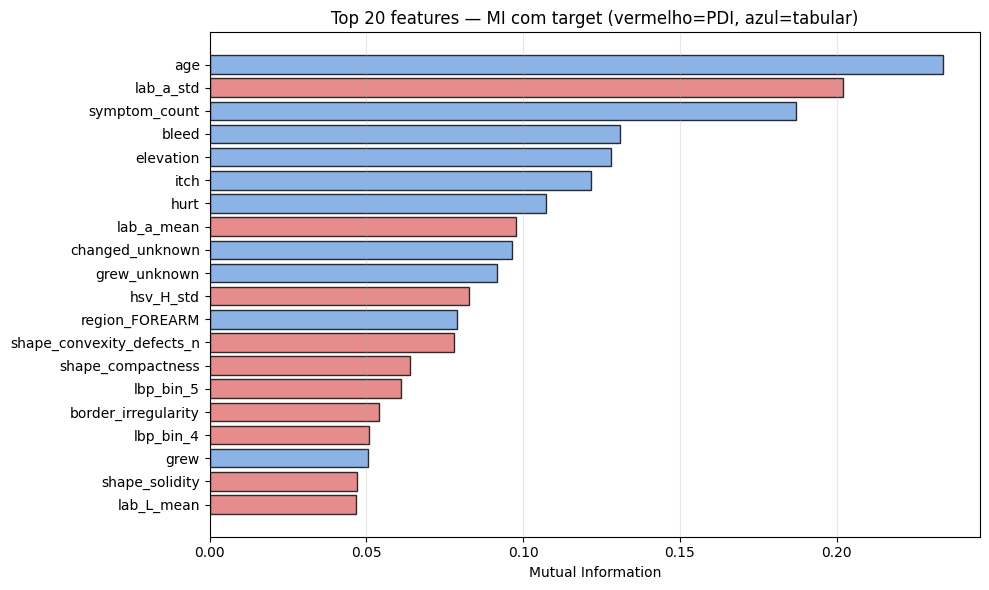

In [15]:
y_train = train_full['y'].values
X_mi = train_full[all_feature_names].values

print('Calculando Mutual Information (~10s)...')
mi = mutual_info_classif(X_mi, y_train, random_state=SEED)
mi_series = pd.Series(mi, index=all_feature_names).sort_values(ascending=False)

# Top 20
top20 = mi_series.head(20)
print('\nTop 20 features por MI:')
for name, score in top20.items():
    kind = '(PDI)' if name in FEATURE_NAMES else '(TAB)'
    print(f'  {name:30s} {kind}  {score:.4f}')

# Leak check
assert mi_series.max() < 0.7, f'LEAK SUSPEITO: {mi_series.idxmax()} tem MI={mi_series.max():.3f}'
print(f'\n✅ Leak check: max MI = {mi_series.max():.3f} (feature: {mi_series.idxmax()})')

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e07070' if n in FEATURE_NAMES else '#70a0e0' for n in top20.index]
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1], edgecolor='black', alpha=0.8)
ax.set_xlabel('Mutual Information')
ax.set_title('Top 20 features — MI com target (vermelho=PDI, azul=tabular)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


## 11. Sanity visual — matriz de correlação das PDI

Heatmap da correlação entre as 38 features PDI. Detecta redundância
extrema (|corr| > 0.95). Não filtra nada — só diagnóstico.


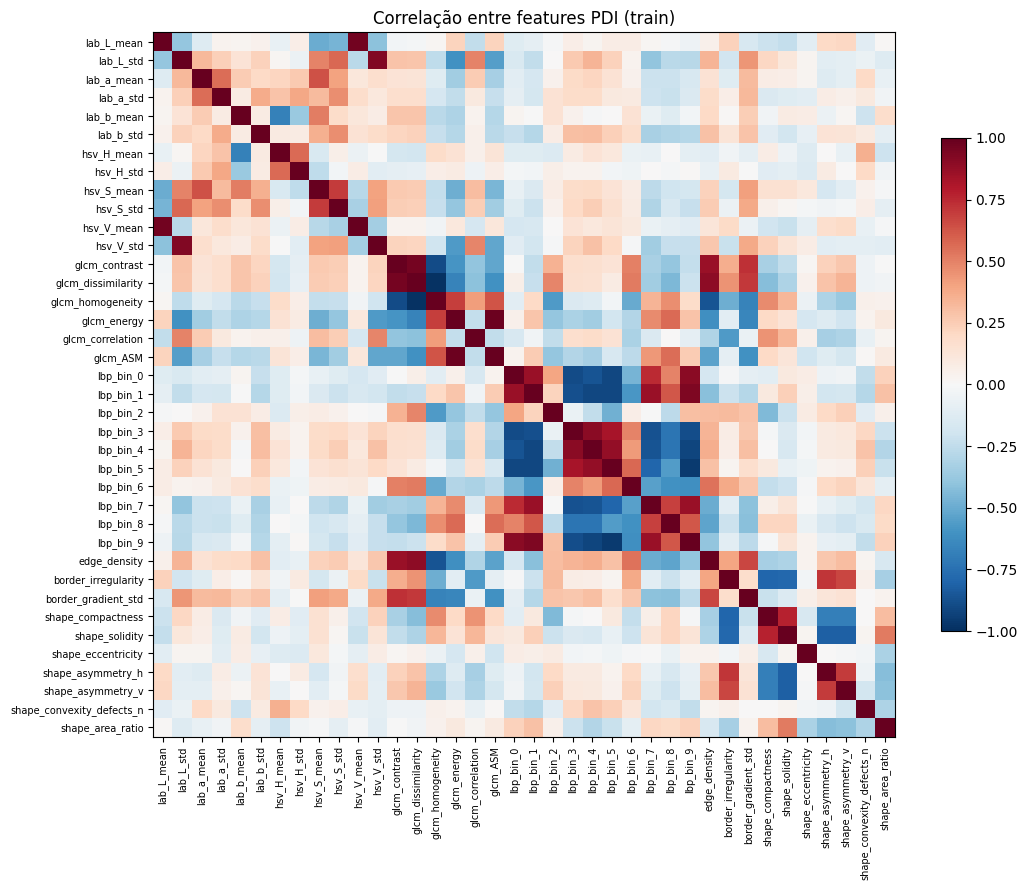


Pares com |corr| > 0.95: 5
  lab_L_mean                ↔ hsv_V_mean                 +0.965
  glcm_contrast             ↔ glcm_dissimilarity         +0.958
  glcm_dissimilarity        ↔ glcm_homogeneity           -0.985
  glcm_energy               ↔ glcm_ASM                   +0.984
  lbp_bin_5                 ↔ lbp_bin_9                  -0.957


In [16]:
corr = train_full[FEATURE_NAMES].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(FEATURE_NAMES)))
ax.set_yticks(range(len(FEATURE_NAMES)))
ax.set_xticklabels(FEATURE_NAMES, rotation=90, fontsize=7)
ax.set_yticklabels(FEATURE_NAMES, fontsize=7)
ax.set_title('Correlação entre features PDI (train)')
plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout(); plt.show()

# Contar pares com |corr| > 0.95 (redundância extrema)
mask_upper = np.triu(np.ones_like(corr, dtype=bool), k=1)
high_corr = (np.abs(corr.values) > 0.95) & mask_upper
pairs = []
for i, j in zip(*np.where(high_corr)):
    pairs.append((FEATURE_NAMES[i], FEATURE_NAMES[j], float(corr.iat[i, j])))

print(f'\nPares com |corr| > 0.95: {len(pairs)}')
for a, b, c in pairs:
    print(f'  {a:25s} ↔ {b:25s}  {c:+.3f}')


## 12. Sanity visual — histogramas das top features por classe

Das 6 features mais informativas (por MI), plota histogramas sobrepostos
das 6 classes. Se as distribuições ficarem bem separadas, a feature é
discriminativa. Se ficarem empilhadas, é redundante ou ruído.


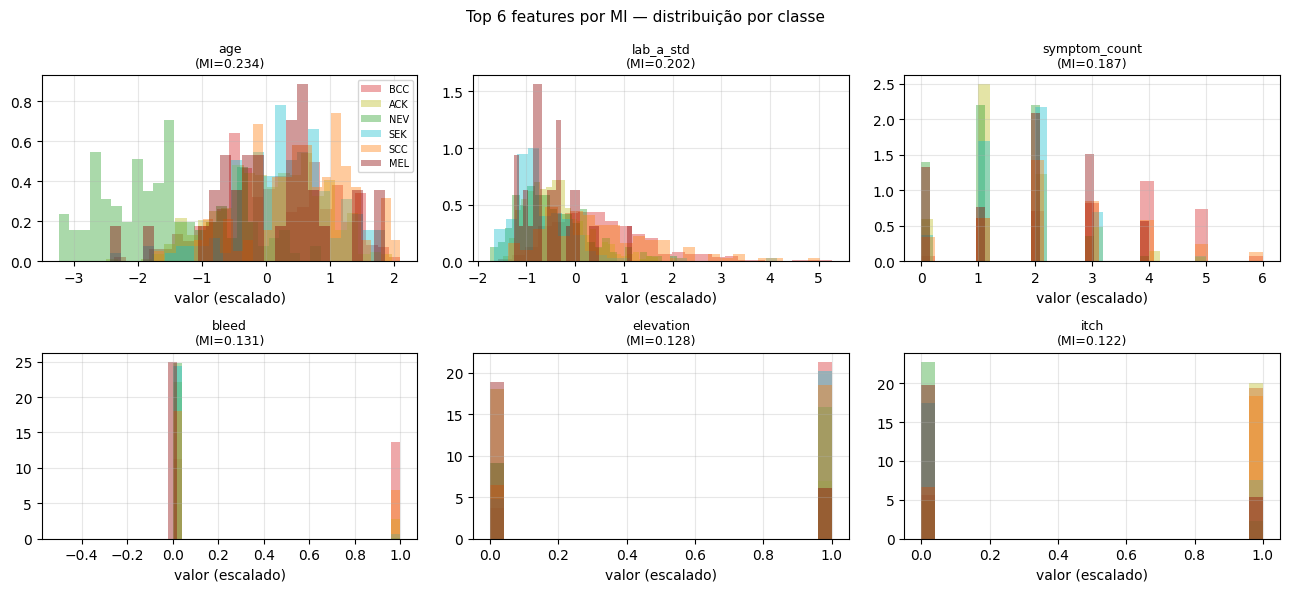

In [17]:
top6 = mi_series.head(6).index.tolist()
CLASS_ORDER = ['BCC', 'ACK', 'NEV', 'SEK', 'SCC', 'MEL']
COLORS = {'BCC':'#d62728','ACK':'#bcbd22','NEV':'#2ca02c',
          'SEK':'#17becf','SCC':'#ff7f0e','MEL':'#8b0000'}

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, feat in zip(axes.flat, top6):
    for cls in CLASS_ORDER:
        vals = train_full.loc[train_full.diagnostic == cls, feat]
        ax.hist(vals, bins=25, alpha=0.4, label=cls, color=COLORS[cls], density=True)
    ax.set_title(f'{feat}\n(MI={mi_series[feat]:.3f})', fontsize=9)
    ax.set_xlabel('valor (escalado)')
    ax.grid(alpha=0.3)

axes[0, 0].legend(fontsize=7, loc='upper right')
plt.suptitle('Top 6 features por MI — distribuição por classe', fontsize=11)
plt.tight_layout(); plt.show()


## 13. Persistência final

Salva os 3 parquets finais + imputer + scaler + feature_names.


In [18]:
# DataFrames finais incluem: features + y + IDs + diagnostic
def build_final(merged):
    cols = all_feature_names + ['y', 'diagnostic', 'patient_id', 'lesion_id', 'img_id']
    return merged[cols].copy()

train_out = build_final(train_full)
val_out   = build_final(val_full)
test_out  = build_final(test_full)

train_out.to_parquet(OUT_DIR / 'train.parquet', index=False)
val_out.to_parquet(  OUT_DIR / 'val.parquet',   index=False)
test_out.to_parquet( OUT_DIR / 'test.parquet',  index=False)

joblib.dump(imputer, OUT_DIR / 'pdi_imputer.joblib')
joblib.dump(scaler,  OUT_DIR / 'pdi_scaler.joblib')

with open(OUT_DIR / 'feature_names.json', 'w') as f:
    json.dump({
        'tabular': tab_feats,
        'pdi': FEATURE_NAMES,
        'all': all_feature_names,
        'n_total': len(all_feature_names),
    }, f, indent=2)

print('✅ Artefatos salvos em', OUT_DIR)
for p in sorted(OUT_DIR.iterdir()):
    size = p.stat().st_size
    unit = 'KB' if size < 1e6 else 'MB'
    val  = size/1024 if size < 1e6 else size/1e6
    print(f'  {p.name:22s} {val:>7.1f} {unit}')


✅ Artefatos salvos em /home/fonsek/CODE/pad-ufes-skin-classification/data/processed/features
  feature_names.json         2.4 KB
  pdi_imputer.joblib         0.8 KB
  pdi_raw.parquet          761.7 KB
  pdi_scaler.joblib          1.5 KB
  test.parquet             203.2 KB
  train.parquet            573.0 KB
  val.parquet              169.7 KB


## 14. Sanity checks finais

In [19]:
tr = pd.read_parquet(OUT_DIR / 'train.parquet')
vl = pd.read_parquet(OUT_DIR / 'val.parquet')
ts = pd.read_parquet(OUT_DIR / 'test.parquet')

# Shapes
assert len(tr) == len(train_tab), f'train shape mismatch: {len(tr)} vs {len(train_tab)}'
assert len(vl) == len(val_tab),   f'val   shape mismatch: {len(vl)} vs {len(val_tab)}'
assert len(ts) == len(test_tab),  f'test  shape mismatch: {len(ts)} vs {len(test_tab)}'
print('✅ Shapes corretos')

# Zero NaN nas features
for name, d in [('train', tr), ('val', vl), ('test', ts)]:
    n = d[all_feature_names].isna().sum().sum()
    assert n == 0, f'{name}: {n} NaN nas features finais'
print('✅ Zero NaN em todas as 62 features finais')

# Zero overlap de patient_id entre splits
assert len(set(tr.patient_id) & set(vl.patient_id)) == 0
assert len(set(tr.patient_id) & set(ts.patient_id)) == 0
assert len(set(vl.patient_id) & set(ts.patient_id)) == 0
print('✅ Zero overlap de patient_id entre splits')

# Todas as 6 classes em todos os splits
for name, d in [('train', tr), ('val', vl), ('test', ts)]:
    classes = set(d.diagnostic.unique())
    assert classes == {'BCC','ACK','NEV','SEK','SCC','MEL'}, f'{name}: classes incompletas'
print('✅ Todas as 6 classes presentes em todos os splits')

# img_id único
for name, d in [('train', tr), ('val', vl), ('test', ts)]:
    assert d.img_id.is_unique
print('✅ img_id único em cada split')

print(f'\nEstado final:')
print(f'  train: {tr.shape} | classes: {dict(tr.diagnostic.value_counts())}')
print(f'  val  : {vl.shape} | classes: {dict(vl.diagnostic.value_counts())}')
print(f'  test : {ts.shape} | classes: {dict(ts.diagnostic.value_counts())}')


✅ Shapes corretos
✅ Zero NaN em todas as 62 features finais
✅ Zero overlap de patient_id entre splits
✅ Todas as 6 classes presentes em todos os splits
✅ img_id único em cada split

Estado final:
  train: (1470, 67) | classes: {'BCC': np.int64(541), 'ACK': np.int64(467), 'NEV': np.int64(156), 'SEK': np.int64(150), 'SCC': np.int64(123), 'MEL': np.int64(33)}
  val  : (368, 67) | classes: {'BCC': np.int64(135), 'ACK': np.int64(117), 'NEV': np.int64(39), 'SEK': np.int64(38), 'SCC': np.int64(30), 'MEL': np.int64(9)}
  test : (460, 67) | classes: {'BCC': np.int64(169), 'ACK': np.int64(146), 'NEV': np.int64(49), 'SEK': np.int64(47), 'SCC': np.int64(39), 'MEL': np.int64(10)}


## 15. Resumo

```
┌─ INPUT ────────────────────────────────────────────┐
│  data/processed/metadata/*.parquet  (24 feat tab)  │
│  data/processed/images/*.npz        (2298 imgs)    │
└────────────────────────────────────────────────────┘
                        ↓
┌─ EXTRAÇÃO PDI (38 features dentro da máscara) ─────┐
│  12 Cor      (LAB + HSV, mean/std)                 │
│   6 GLCM     (Haralick, 32 níveis, 4 ângulos)      │
│  10 LBP      (R=1 uniforme, 10 bins)               │
│   3 Bordas   (density, irregularity, grad_std)     │
│   7 Forma    (ABCDE via máscara)                   │
└────────────────────────────────────────────────────┘
                        ↓
┌─ IMPUTE + SCALE + MERGE (tudo fit só no train) ────┐
│  imputer (mediana) → scaler (StandardScaler)       │
│  merge via img_id (validate='one_to_one')          │
└────────────────────────────────────────────────────┘
                        ↓
┌─ OUTPUT ───────────────────────────────────────────┐
│  data/processed/features/                          │
│    train.parquet  val.parquet  test.parquet        │
│    pdi_imputer.joblib  pdi_scaler.joblib           │
│    pdi_raw.parquet (cache)  feature_names.json     │
│                                                    │
│  24 tabulares + 38 PDI = 62 features finais        │
└────────────────────────────────────────────────────┘
```

### Próximo notebook

`05_modelagem.ipynb` — baseline de ML clássico (RF, XGBoost, SVM, LogReg)
com `class_weight='balanced'`, hyperparameter tuning do melhor, e
comparação entre "só tabular", "só PDI", "combinado".
